This is the notebook to visualize and check the dataset.

In [1]:
import torch

# Check if GPU is available
gpu_available = torch.cuda.is_available()
print(f"Is GPU available? {gpu_available}")

ModuleNotFoundError: No module named 'torch'

In [5]:
import os
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np

def explore_adni_directory(base_path):
    """
    Explore and analyze the ADNI directory structure and files
    
    Args:
        base_path (str): Path to the ADNI directory
    """
    # Convert to Path object for easier handling
    base_dir = Path(base_path)
    
    # Initialize data collection
    file_info = []
    
    # Walk through directory
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(('.nii', '.nii.gz')):
                full_path = Path(root) / file
                relative_path = full_path.relative_to(base_dir)
                
                try:
                    # Load NIfTI file
                    img = nib.load(str(full_path))
                    data = img.get_fdata()
                    
                    file_info.append({
                        'filename': file,
                        'relative_path': str(relative_path),
                        'size_mb': full_path.stat().st_size / (1024 * 1024),
                        'shape': data.shape,
                        'data_type': str(data.dtype),
                        'min_value': np.min(data),
                        'max_value': np.max(data),
                        'mean_value': np.mean(data)
                    })
                except Exception as e:
                    print(f"Error processing {file}: {str(e)}")
    
    # Convert to DataFrame for easier analysis
    df = pd.DataFrame(file_info)
    
    # Print summary
    print("\n=== ADNI Directory Analysis ===")
    print(f"\nBase Path: {base_path}")
    print(f"Total number of NIfTI files: {len(df)}")
    print("\nDirectory Structure:")
    print_directory_tree(base_dir)
    
    print("\nFile Statistics:")
    print(f"Average file size: {df['size_mb'].mean():.2f} MB")
    print(f"Total size: {df['size_mb'].sum():.2f} MB")
    
    if not df.empty:
        print("\nImage Dimensions:")
        print(df['shape'].value_counts().to_string())
        
        print("\nData Types:")
        print(df['data_type'].value_counts().to_string())
    
    return df

def print_directory_tree(path, level=0, max_level=3):
    """
    Print directory tree structure
    """
    if level > max_level:
        return
        
    indent = "  " * level
    path_obj = Path(path)
    
    try:
        # Print current directory
        print(f"{indent}└── {path_obj.name}/")
        
        # Recursively print subdirectories
        for item in path_obj.iterdir():
            if item.is_dir():
                print_directory_tree(item, level + 1, max_level)
            elif level == max_level and item.suffix in ['.nii', '.nii.gz']:
                print(f"{indent}    └── {item.name}")
    except PermissionError:
        print(f"{indent}    ⚠️  Permission denied")

def analyze_sample_image(file_path):
    """
    Analyze a sample NIfTI image in detail
    """
    img = nib.load(file_path)
    data = img.get_fdata()
    
    print(f"\n=== Sample Image Analysis: {Path(file_path).name} ===")
    print(f"Dimensions: {data.shape}")
    print(f"Data type: {data.dtype}")
    print(f"Value range: [{np.min(data):.2f}, {np.max(data):.2f}]")
    print(f"Mean value: {np.mean(data):.2f}")
    print(f"Standard deviation: {np.std(data):.2f}")
    print("\nHeader information:")
    print(img.header)
    
    return img, data

# Main execution
if __name__ == "__main__":
    adni_path = r"E:/KHU Gangdong Hospital Data/PET1_FDG/ADNI1"
    df = explore_adni_directory(adni_path)


=== ADNI Directory Analysis ===

Base Path: E:/KHU Gangdong Hospital Data/PET1_FDG/ADNI1
Total number of NIfTI files: 5777

Directory Structure:
└── ADNI1/

File Statistics:
Average file size: 0.90 MB
Total size: 5208.41 MB

Image Dimensions:
shape
(79, 95, 79)    5777

Data Types:
data_type
float64    5777



Validating 100 images...


100%|██████████| 100/100 [00:00<00:00, 208.24it/s]



=== Validation Results ===
Total files processed: 100
Valid files: 100
Invalid files: 0

Statistics for valid files:
Shape distribution: {(79, 95, 79)}
Data types: {'float64'}
Value ranges: [-1188.19, 29114.97]
Files with NaN values: 6
Files with Inf values: 0


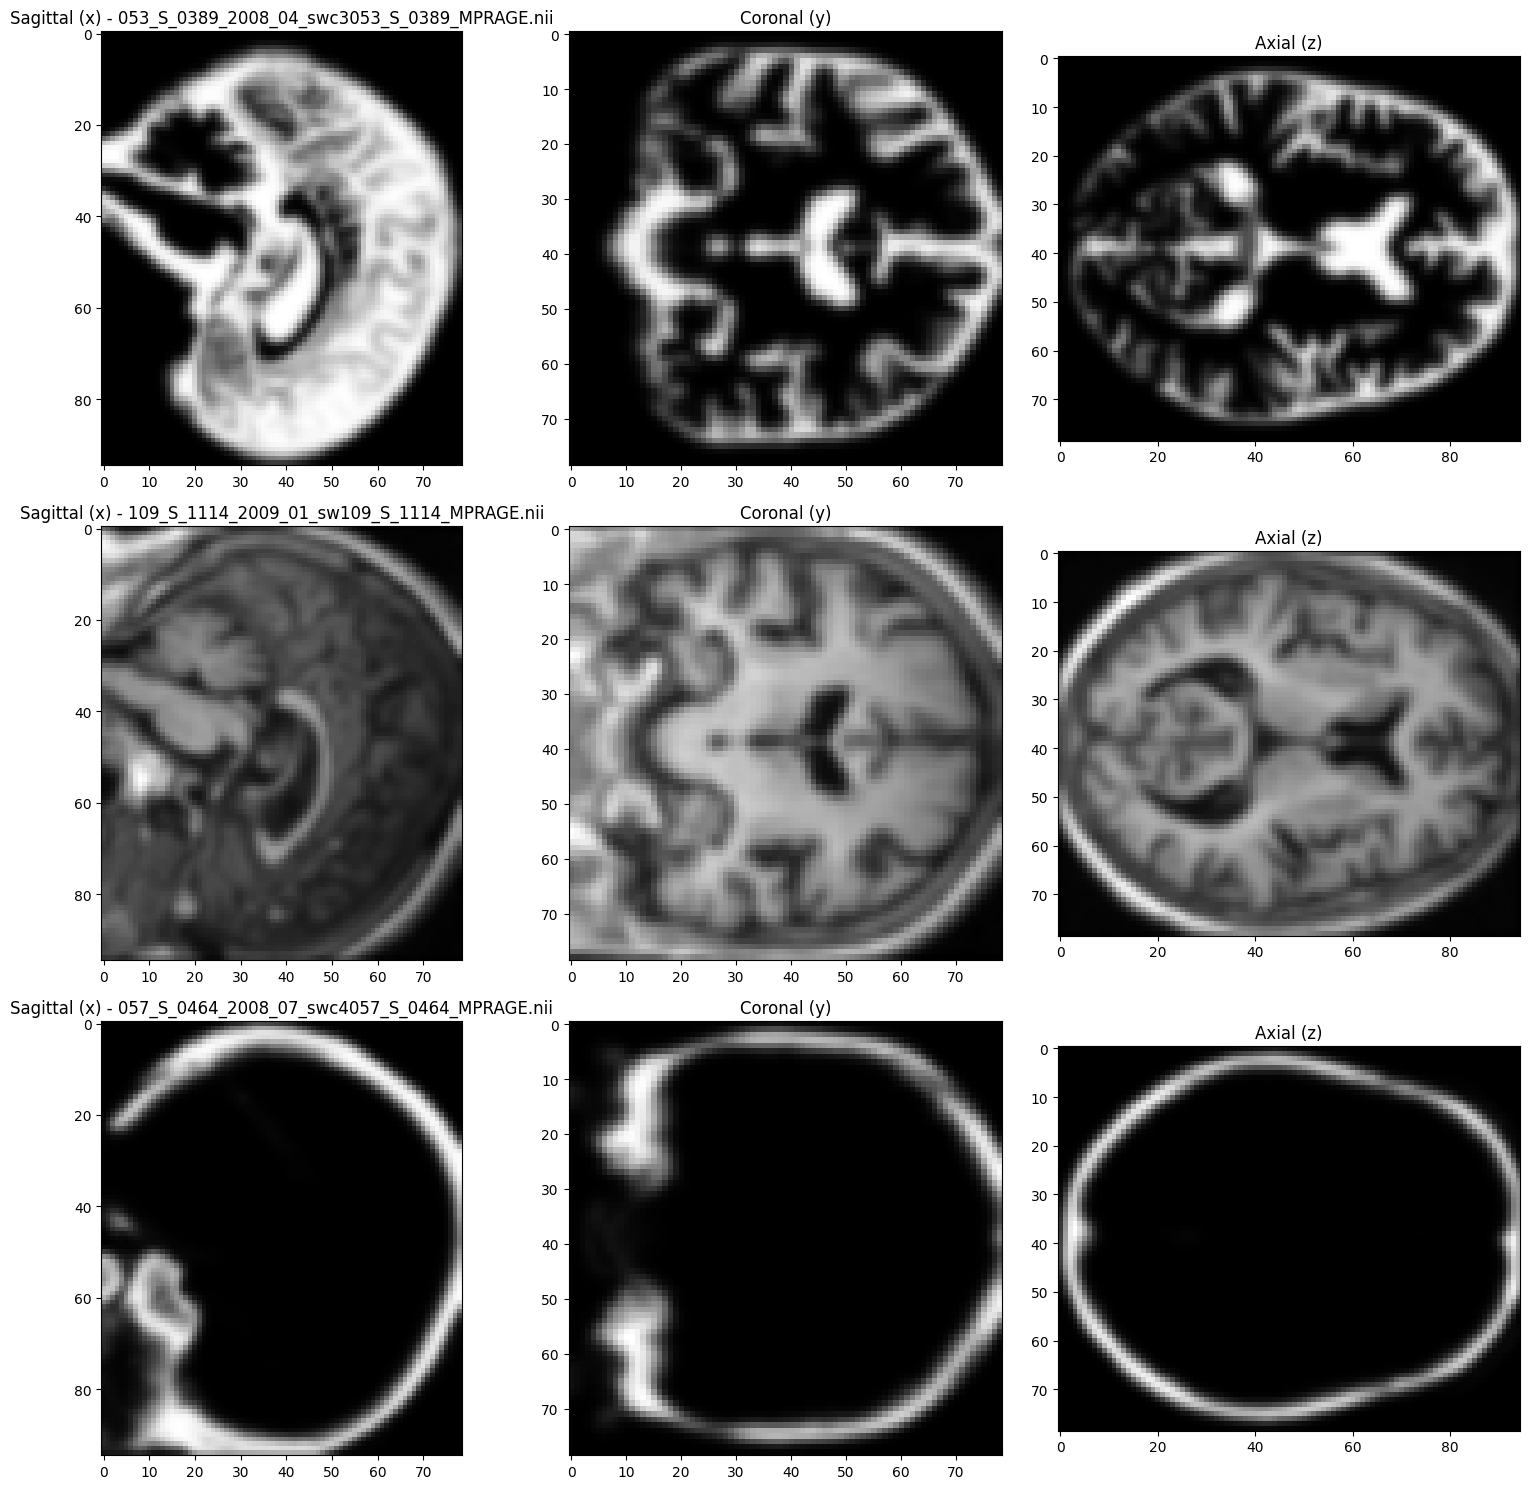

In [9]:
#Lets check that if Python can properly load and process the images of the dataset, that are in the nii format.

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

class PETImageValidator:
    def __init__(self, base_path):
        self.base_path = Path(base_path)
        self.validation_results = []
        
    def get_all_nifti_files(self):
        """Get all .nii files in the directory"""
        return list(self.base_path.rglob("*.nii"))
    
    def validate_single_image(self, file_path):
        """Validate a single NIfTI file"""
        try:
            # Load the image
            img = nib.load(str(file_path))
            data = img.get_fdata()
            
            # Basic checks
            validation = {
                'file_path': str(file_path),
                'filename': file_path.name,
                'status': 'valid',
                'shape': data.shape,
                'data_type': str(data.dtype),
                'min_value': float(np.min(data)),
                'max_value': float(np.max(data)),
                'mean_value': float(np.mean(data)),
                'has_nan': np.isnan(data).any(),
                'has_inf': np.isinf(data).any(),
                'file_size_mb': file_path.stat().st_size / (1024 * 1024)
            }
            
        except Exception as e:
            validation = {
                'file_path': str(file_path),
                'filename': file_path.name,
                'status': 'invalid',
                'error': str(e)
            }
            
        return validation
    
    def validate_dataset(self, sample_size=None):
        """Validate all images or a sample of them"""
        files = self.get_all_nifti_files()
        
        if sample_size and sample_size < len(files):
            files = np.random.choice(files, sample_size, replace=False)
        
        print(f"\nValidating {len(files)} images...")
        
        for file in tqdm(files):
            result = self.validate_single_image(file)
            self.validation_results.append(result)
            
        return self.analyze_results()
    
    def analyze_results(self):
        """Analyze validation results"""
        valid_results = [r for r in self.validation_results if r['status'] == 'valid']
        invalid_results = [r for r in self.validation_results if r['status'] == 'invalid']
        
        print("\n=== Validation Results ===")
        print(f"Total files processed: {len(self.validation_results)}")
        print(f"Valid files: {len(valid_results)}")
        print(f"Invalid files: {len(invalid_results)}")
        
        if valid_results:
            print("\nStatistics for valid files:")
            print(f"Shape distribution: {set(r['shape'] for r in valid_results)}")
            print(f"Data types: {set(r['data_type'] for r in valid_results)}")
            print(f"Value ranges: [{min(r['min_value'] for r in valid_results):.2f}, "
                  f"{max(r['max_value'] for r in valid_results):.2f}]")
            print(f"Files with NaN values: {sum(1 for r in valid_results if r['has_nan'])}")
            print(f"Files with Inf values: {sum(1 for r in valid_results if r['has_inf'])}")
            
        if invalid_results:
            print("\nInvalid files:")
            for r in invalid_results:
                print(f"- {r['filename']}: {r['error']}")
    
    def visualize_sample_images(self, num_samples=3):
        """Visualize sample images to verify they load correctly"""
        valid_files = [r['file_path'] for r in self.validation_results 
                      if r['status'] == 'valid']
        
        if not valid_files:
            print("No valid files to visualize")
            return
        
        samples = np.random.choice(valid_files, min(num_samples, len(valid_files)), 
                                 replace=False)
        
        fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
        if num_samples == 1:
            axes = axes[np.newaxis, :]
            
        for i, file_path in enumerate(samples):
            img = nib.load(file_path)
            data = img.get_fdata()
            
            # Get middle slices
            slice_x = data[data.shape[0]//2, :, :]
            slice_y = data[:, data.shape[1]//2, :]
            slice_z = data[:, :, data.shape[2]//2]
            
            # Plot
            axes[i, 0].imshow(slice_x, cmap='gray')
            axes[i, 0].set_title(f'Sagittal (x) - {Path(file_path).name}')
            
            axes[i, 1].imshow(slice_y, cmap='gray')
            axes[i, 1].set_title('Coronal (y)')
            
            axes[i, 2].imshow(slice_z, cmap='gray')
            axes[i, 2].set_title('Axial (z)')
            
        plt.tight_layout()
        plt.show()

# Usage example
if __name__ == "__main__":
    adni_path = r"E:/KHU Gangdong Hospital Data/PET1_FDG/ADNI1"
    
    # Create validator instance
    validator = PETImageValidator(adni_path)
    
    # Validate a sample of 100 images (adjust as needed)
    validator.validate_dataset(sample_size=100)
    
    # Visualize 3 random samples
    validator.visualize_sample_images(num_samples=3)